In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Linear Regression

In [2]:
x = np.linspace(-3, 3, 100)
print(x)

[-3.         -2.93939394 -2.87878788 -2.81818182 -2.75757576 -2.6969697
 -2.63636364 -2.57575758 -2.51515152 -2.45454545 -2.39393939 -2.33333333
 -2.27272727 -2.21212121 -2.15151515 -2.09090909 -2.03030303 -1.96969697
 -1.90909091 -1.84848485 -1.78787879 -1.72727273 -1.66666667 -1.60606061
 -1.54545455 -1.48484848 -1.42424242 -1.36363636 -1.3030303  -1.24242424
 -1.18181818 -1.12121212 -1.06060606 -1.         -0.93939394 -0.87878788
 -0.81818182 -0.75757576 -0.6969697  -0.63636364 -0.57575758 -0.51515152
 -0.45454545 -0.39393939 -0.33333333 -0.27272727 -0.21212121 -0.15151515
 -0.09090909 -0.03030303  0.03030303  0.09090909  0.15151515  0.21212121
  0.27272727  0.33333333  0.39393939  0.45454545  0.51515152  0.57575758
  0.63636364  0.6969697   0.75757576  0.81818182  0.87878788  0.93939394
  1.          1.06060606  1.12121212  1.18181818  1.24242424  1.3030303
  1.36363636  1.42424242  1.48484848  1.54545455  1.60606061  1.66666667
  1.72727273  1.78787879  1.84848485  1.90909091  1.9

In [3]:
rng = np.random.RandomState(42)
y = np.sin(4 * x) + x + rng.uniform(size=len(x))

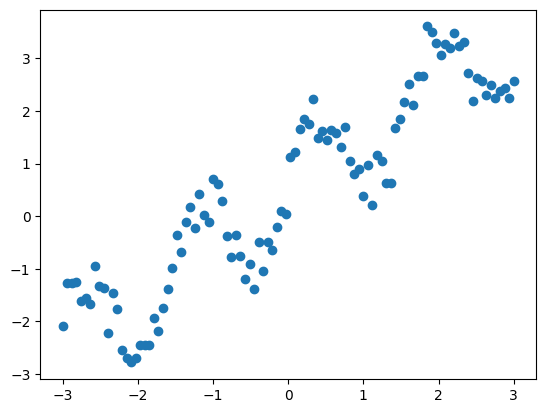

In [4]:
plt.plot(x, y, 'o')

In [5]:
print("Before: ", x.shape)
X = x[:, np.newaxis]
print("After: ", X.shape)

Before:  (100,)
After:  (100, 1)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## y = weight * x + intercept

In [8]:
print("Weight coefficients: ", regressor.coef_)
print("y-axis intercept: ", regressor.intercept_)

Weight coefficients:  [0.90211711]
y-axis intercept:  0.44840974988268


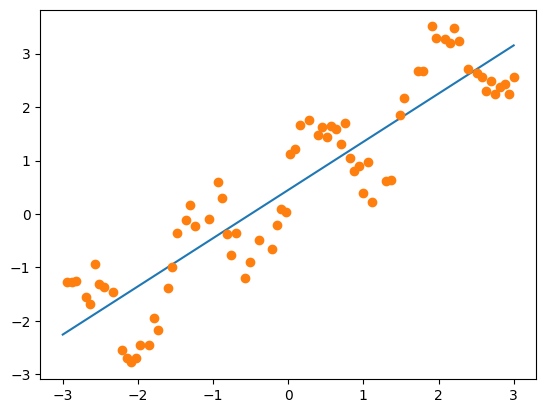

In [9]:
min_pt = X.min() * regressor.coef_[0] + regressor.intercept_   # X.min = -3
max_pt = X.max() * regressor.coef_[0] + regressor.intercept_   # X.max = 3

plt.plot([X.min(), X.max()], [min_pt, max_pt])
plt.plot(X_train, y_train, 'o')
plt.show()

In [10]:
y_pred_train = regressor.predict(X_train)

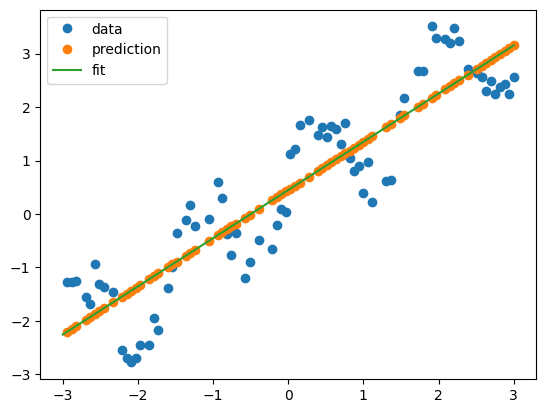

In [11]:
plt.plot(X_train, y_train, 'o', label="data")
plt.plot(X_train, y_pred_train, 'o', label="prediction")
plt.plot([X.min(), X.max()], [min_pt, max_pt], label="fit")
plt.legend(loc='best')
plt.show()

In [12]:
y_pred_test = regressor.predict(X_test)

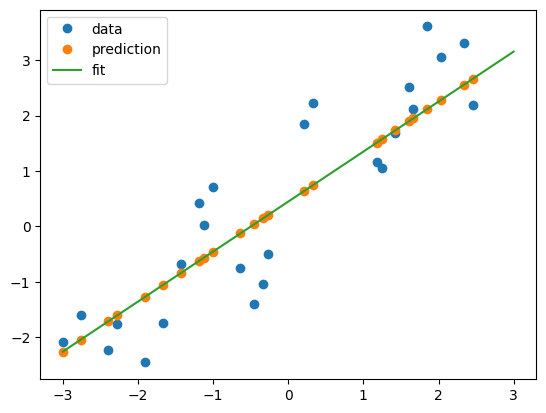

In [13]:
plt.plot(X_test, y_test, 'o', label="data")
plt.plot(X_test, y_pred_test, 'o', label="prediction")
plt.plot([X.min(), X.max()], [min_pt, max_pt], label="fit")
plt.legend(loc='best')
plt.show()

In [14]:
regressor.score(X_test, y_test)

0.7994321405079685

In [15]:
regressor.score(X_train, y_train)

0.8189190775347295

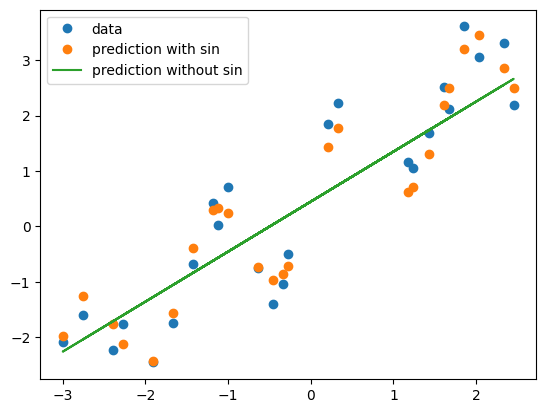

In [16]:
XX_train = np.concatenate((X_train, np.sin(4 * X_train)), axis=1)
XX_test = np.concatenate((X_test, np.sin(4 * X_test)), axis=1)
regressor.fit(XX_train, y_train)
y_pred_test_sin = regressor.predict(XX_test)

plt.plot(X_test, y_test, 'o', label="data")
plt.plot(X_test, y_pred_test_sin, 'o', label="prediction with sin")
plt.plot(X_test, y_pred_test, label="prediction without sin")
plt.legend(loc='best')
plt.show()